# Model ID (hand) — kinematic fitting

Fits transmission models for all joints of the ADAPT Hand from recorded (θ, q) pairs.
Saves fitted coefficients to `hand_params.py`.

In [1]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import pandas as pd
import os, sys, re

sys.path.insert(0, '..')
from plot_config import draw_radar, COLORS, FIG_W_SINGLE, FIG_W_DOUBLE

In [2]:
def load_joint_data(filename):
    filepath = os.path.join('outputs/joint_data', filename)
    df = pd.read_csv(filepath)
    data = [(np.radians(row['q_deg']), np.radians(row['theta_deg'])) for _, row in df.iterrows()]
    print(f"Loaded {len(data)} points from {filepath}")
    return data


def fit_linear_model(data):
    def mse_cost(k):
        return np.mean([(k * theta - q)**2 for q, theta in data])
    result = minimize(mse_cost, [1.0], method='L-BFGS-B')
    k_sol = result.x[0]
    q_values = [q for q, _ in data]
    ss_tot = sum((q - np.mean(q_values))**2 for q in q_values)
    ss_res = sum((q - k_sol * theta)**2 for q, theta in data)
    r_squared = 1 - ss_res / ss_tot
    print(f"  k = {k_sol:.6f}  MSE = {result.fun:.6f}  R² = {r_squared:.6f}")
    return {'k': k_sol, 'mse': result.fun, 'r_squared': r_squared}


def fit_pulley_model(data, R=0.005):
    def mse_cost(r_pulley):
        return np.mean([((R / r_pulley) * q - theta)**2 for q, theta in data])
    result = minimize(mse_cost, [0.01], method='L-BFGS-B', bounds=[(1e-6, None)])
    r_sol = result.x[0]
    theta_values = [theta for _, theta in data]
    ss_tot = sum((t - np.mean(theta_values))**2 for t in theta_values)
    r_squared = 1 - (result.fun * len(data)) / ss_tot
    print(f"  r_pulley = {r_sol:.6f} m  R/r = {R/r_sol:.6f}  R² = {r_squared:.6f}")
    return {'r_pulley': r_sol, 'R': R, 'mse': result.fun, 'r_squared': r_squared}


def plot_linear_fit(data, k, xlabel=r'$\theta$ ($^\circ$)', color_fit='C0', color_data='C1'):
    q_meas_deg    = np.degrees([q for q, _ in data])
    theta_meas_deg = np.degrees([theta for _, theta in data])
    theta_fit = np.linspace(0, max(theta_meas_deg), 100)
    fig, ax = plt.subplots()
    ax.plot(theta_fit, k * theta_fit, '--', color=color_fit, label=r'$q = k \cdot \theta$')
    ax.plot(theta_meas_deg, q_meas_deg, 'o', color=color_data, label='Measured')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r'$q$ ($^\circ$)')
    ax.legend(fontsize='small')
    fig.tight_layout()
    plt.show()


def plot_pulley_fit(data, r_pulley, R, color_fit='C0', color_data='C1'):
    q_meas_deg    = np.degrees([q for q, _ in data])
    theta_meas_deg = np.degrees([theta for _, theta in data])
    q_fit = np.linspace(0, max(q_meas_deg), 100)
    fig, ax = plt.subplots()
    ax.plot(q_fit, (R / r_pulley) * q_fit, '--', color=color_fit,
            label=r'$\theta = \frac{R}{r}\,q$')
    ax.plot(q_meas_deg, theta_meas_deg, 'o', color=color_data, label='Measured')
    ax.set_xlabel(r'$q$ ($^\circ$)')
    ax.set_ylabel(r'$\theta$ ($^\circ$)')
    ax.legend(fontsize='small')
    fig.tight_layout()
    plt.show()

---
## 1. Thumb Joints

### 1.1 Thumb CMC1 (flexion/extension) — Pulley model

Loaded 5 points from outputs/joint_data/thumb_CMC1_joint_data.csv
  r_pulley = 0.013457 m  R/r = 0.371559  R² = 0.976899


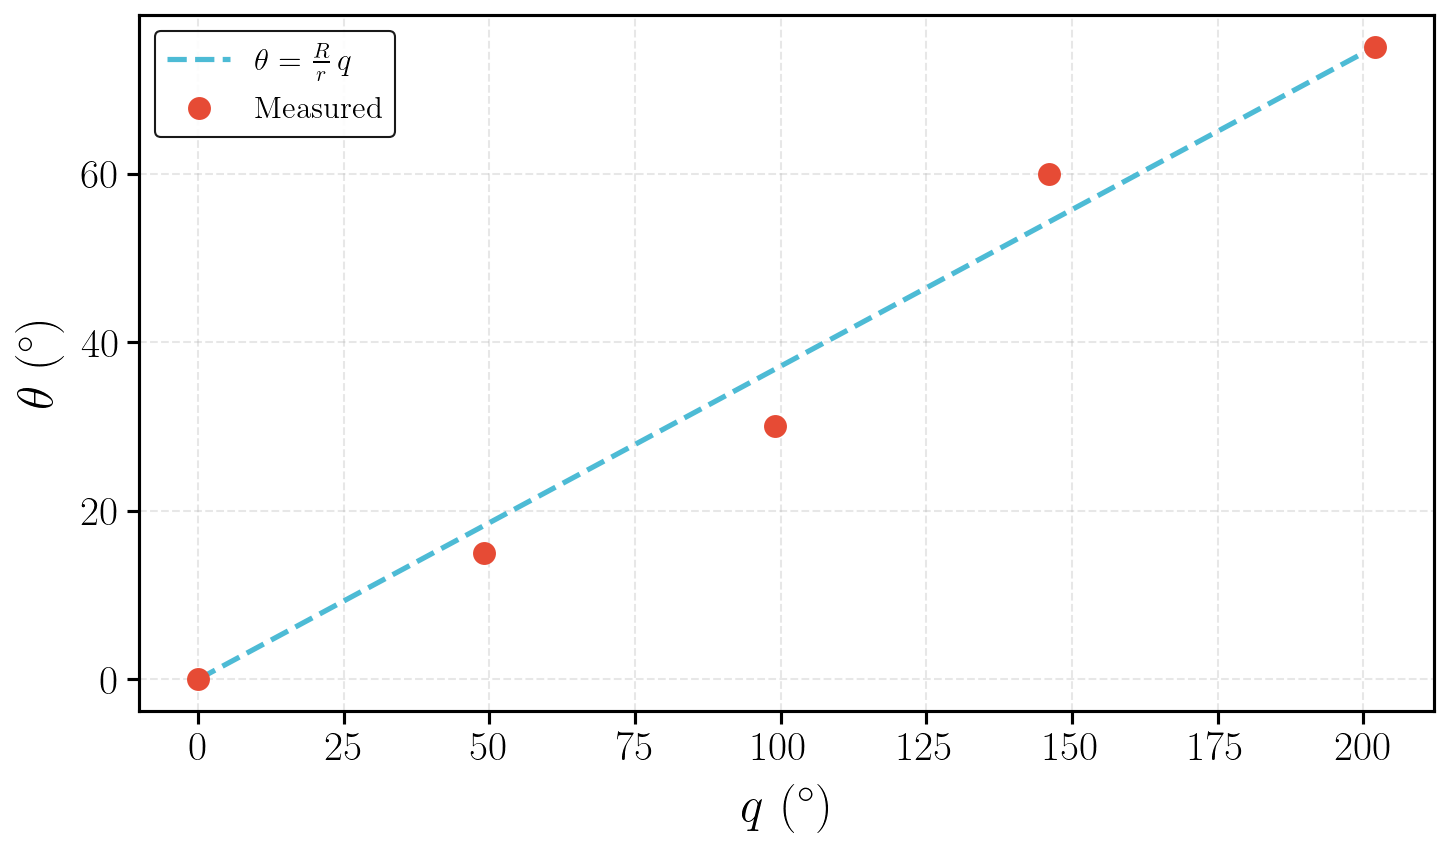

In [3]:
data_CMC1 = load_joint_data('thumb_CMC1_joint_data.csv')
res_CMC1 = fit_pulley_model(data_CMC1, R=0.005)
plot_pulley_fit(data_CMC1, res_CMC1['r_pulley'], res_CMC1['R'])

### 1.2 Thumb CMC2 (abduction/adduction) — Pulley model

Loaded 5 points from outputs/joint_data/thumb_CMC2_joint_data.csv
  r_pulley = 0.008834 m  R/r = 0.565967  R² = 0.975535


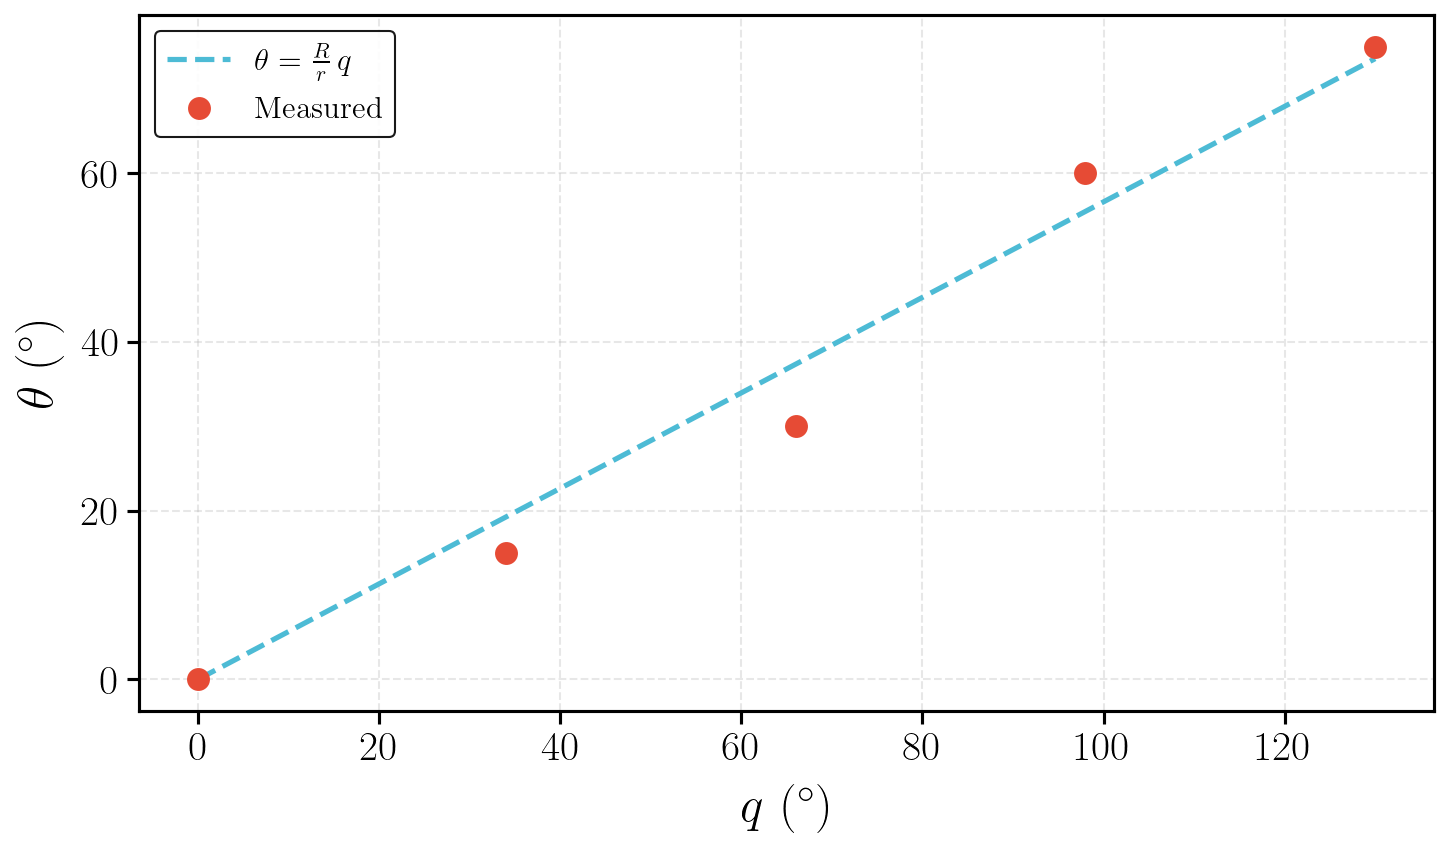

In [4]:
data_CMC2 = load_joint_data('thumb_CMC2_joint_data.csv')
res_CMC2 = fit_pulley_model(data_CMC2, R=0.005)
plot_pulley_fit(data_CMC2, res_CMC2['r_pulley'], res_CMC2['R'])

### 1.3 Thumb MCP — Linear model

Loaded 6 points from outputs/joint_data/thumb_MCP_joint_data.csv
  k = 1.209697  MSE = 0.000550  R² = 0.998067
  => c_MCP = k * r_motor = 0.006048 m


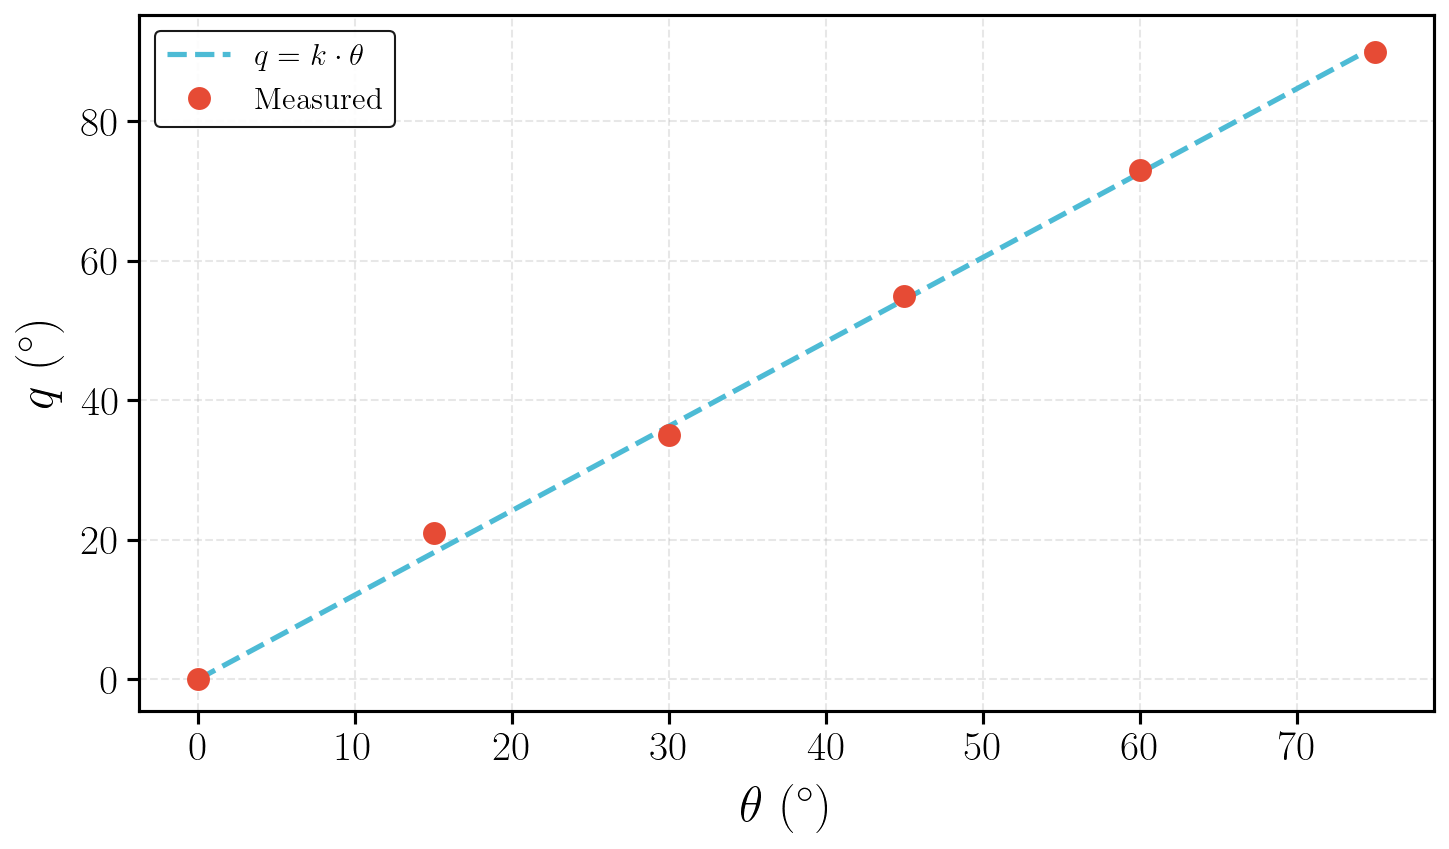

In [5]:
data_thumb_MCP = load_joint_data('thumb_MCP_joint_data.csv')
res_thumb_MCP = fit_linear_model(data_thumb_MCP)
print(f"  => c_MCP = k * r_motor = {res_thumb_MCP['k'] * 0.005:.6f} m")
plot_linear_fit(data_thumb_MCP, res_thumb_MCP['k'])

### 1.4 Thumb IP — Linear model

Loaded 6 points from outputs/joint_data/thumb_IP_joint_data.csv
  k = 1.153939  MSE = 0.001459  R² = 0.994422
  => c_IP = k * r_motor = 0.005770 m


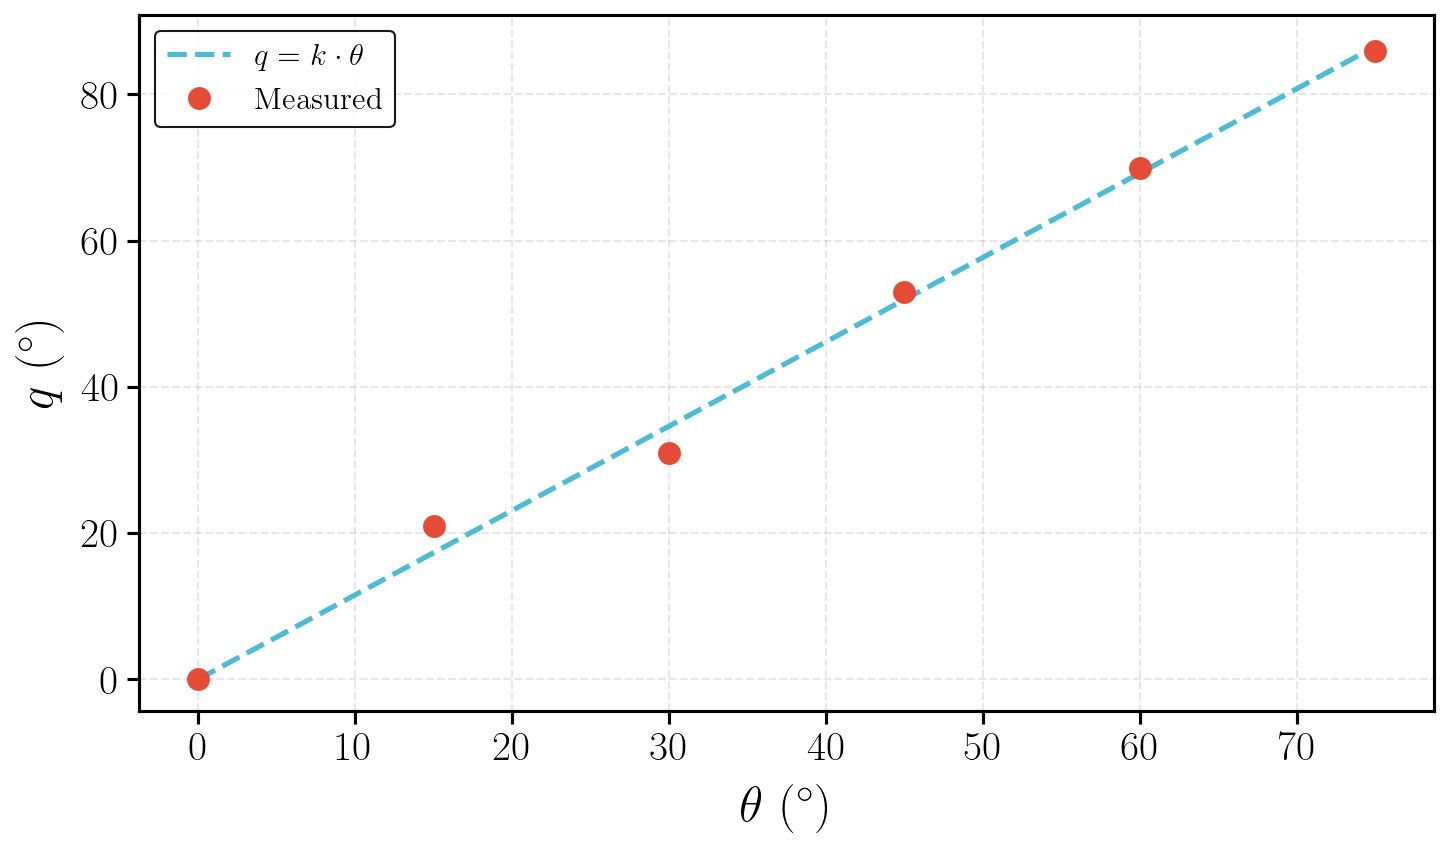

In [6]:
data_thumb_IP = load_joint_data('thumb_IP_joint_data.csv')
res_thumb_IP = fit_linear_model(data_thumb_IP)
print(f"  => c_IP = k * r_motor = {res_thumb_IP['k'] * 0.005:.6f} m")
plot_linear_fit(data_thumb_IP, res_thumb_IP['k'])

---
## 2. Index Finger

=== Index MCP ===
Loaded 6 points from outputs/joint_data/index_MCP_joint_data.csv
  k = 1.643636  MSE = 0.000428  R² = 0.999206
  => r_pulley = r_motor / k = 0.003042 m


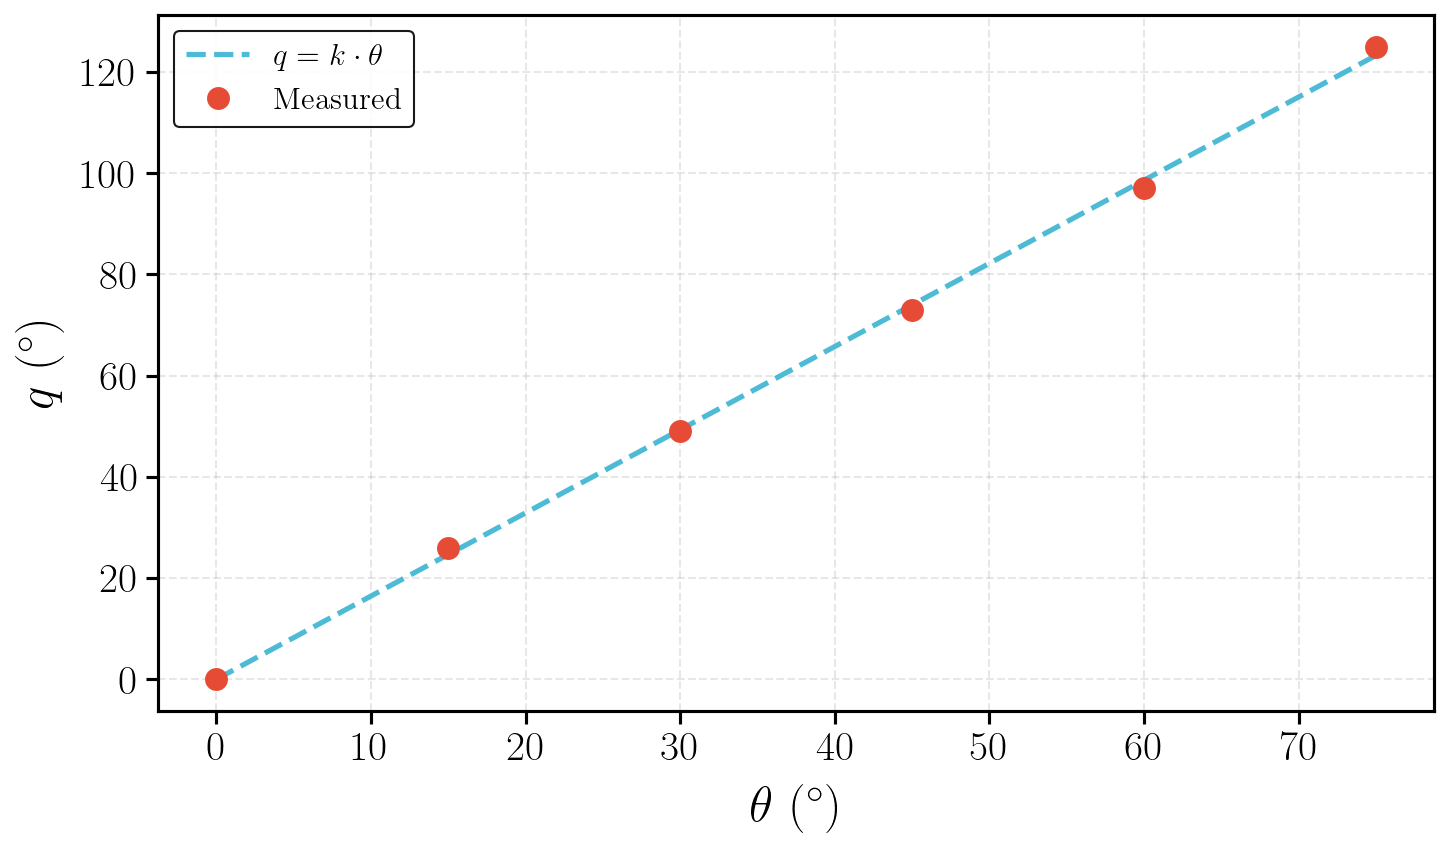


=== Index PIP ===
Loaded 6 points from outputs/joint_data/index_PIP_joint_data.csv
  k = 2.179394  MSE = 0.004962  R² = 0.994531
  => c_param = k * r_motor = 0.010897 m


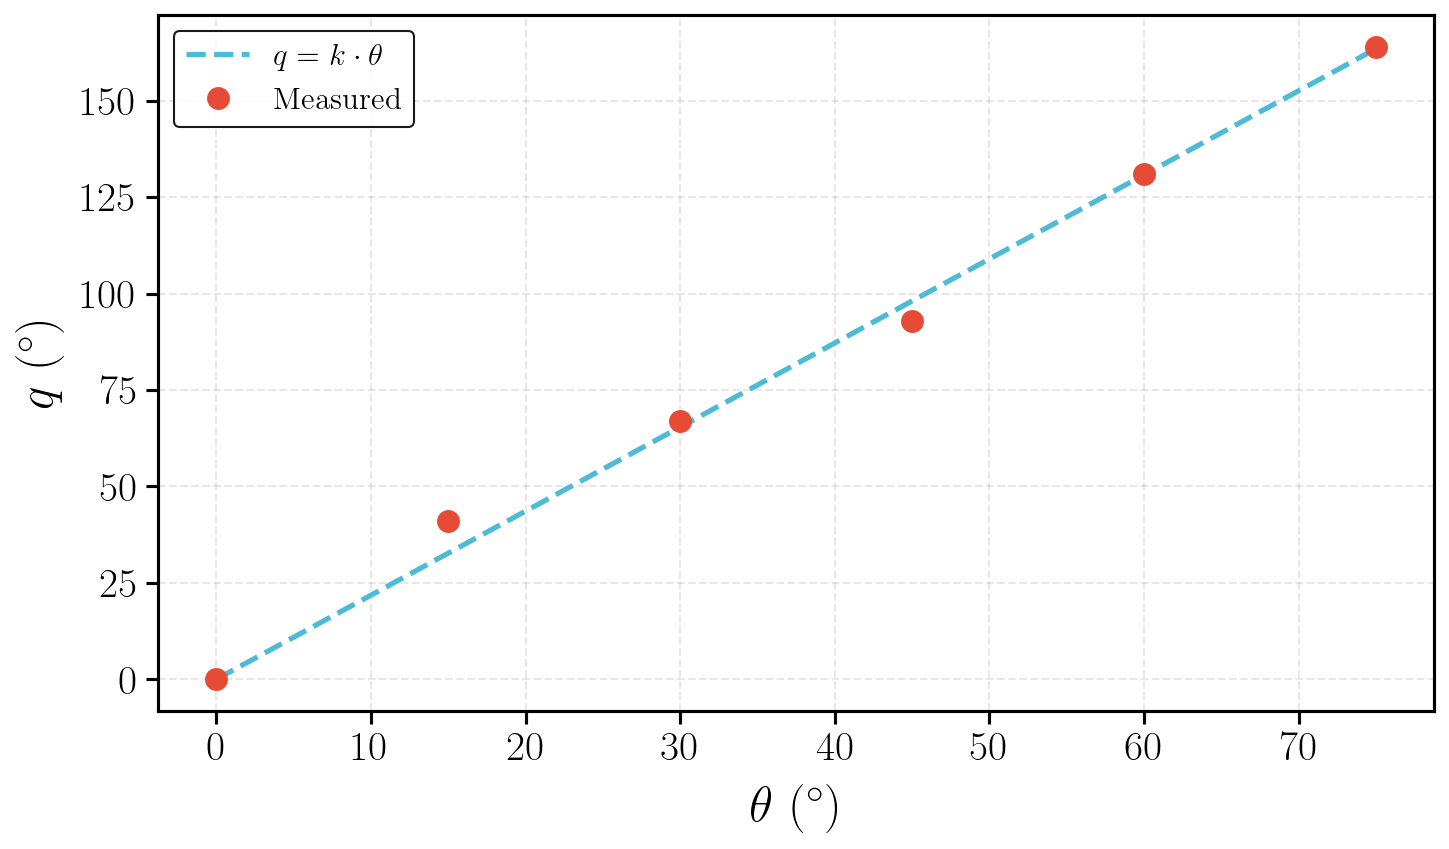

In [7]:
print("=== Index MCP ===")
data_index_MCP = load_joint_data('index_MCP_joint_data.csv')
res_index_MCP = fit_linear_model(data_index_MCP)
print(f"  => r_pulley = r_motor / k = {0.005 / res_index_MCP['k']:.6f} m")
plot_linear_fit(data_index_MCP, res_index_MCP['k'])

print("\n=== Index PIP ===")
data_index_PIP = load_joint_data('index_PIP_joint_data.csv')
res_index_PIP = fit_linear_model(data_index_PIP)
print(f"  => c_param = k * r_motor = {res_index_PIP['k'] * 0.005:.6f} m")
plot_linear_fit(data_index_PIP, res_index_PIP['k'])

---
## 3. Middle Finger

=== Middle MCP ===
Loaded 6 points from outputs/joint_data/middle_MCP_joint_data.csv
  k = 1.643636  MSE = 0.000428  R² = 0.999206
  => r_pulley = r_motor / k = 0.003042 m


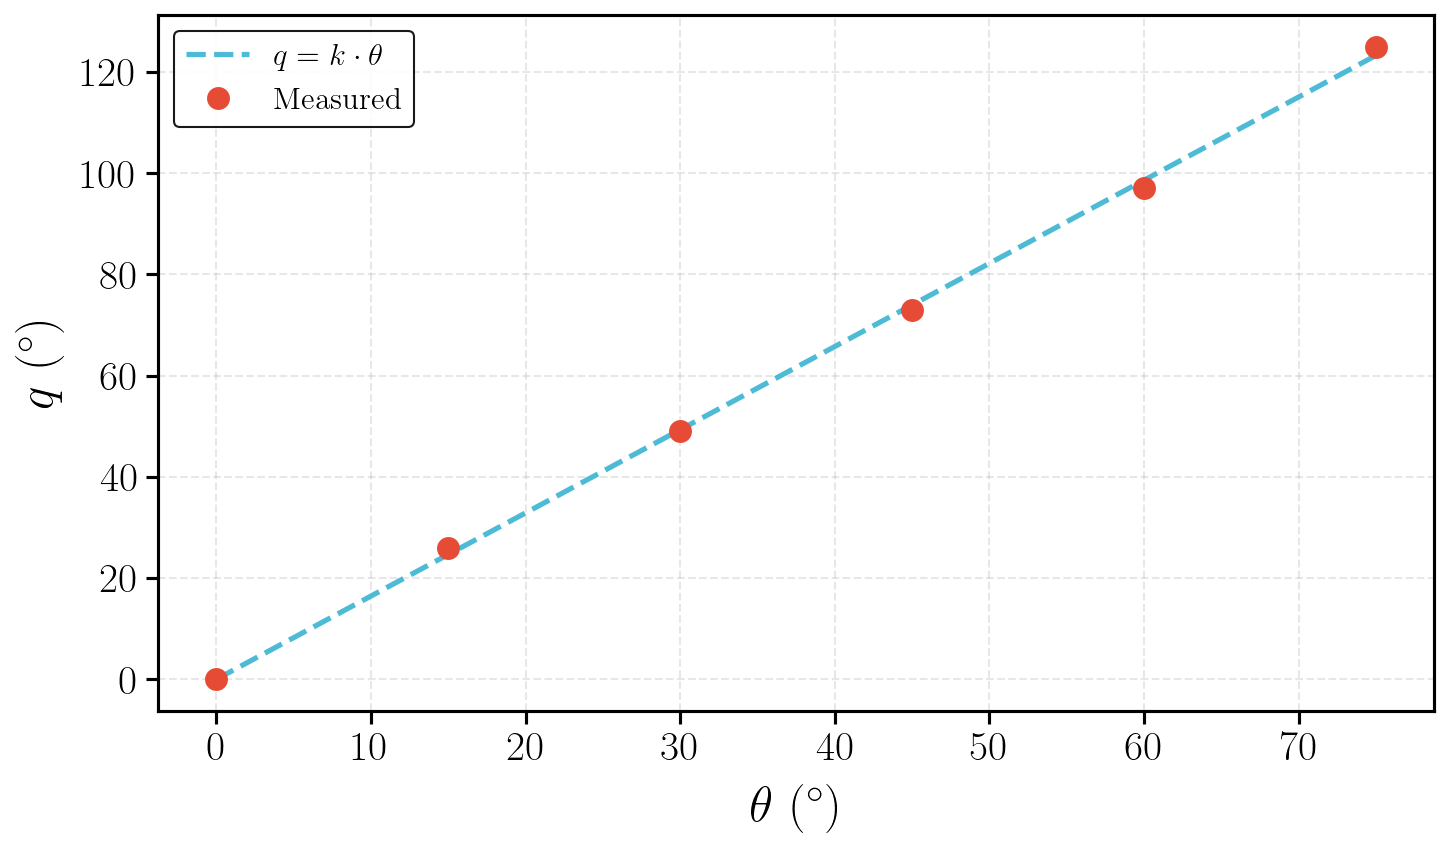


=== Middle PIP ===
Loaded 6 points from outputs/joint_data/middle_PIP_joint_data.csv
  k = 2.253333  MSE = 0.009636  R² = 0.989822
  => c_param = k * r_motor = 0.011267 m


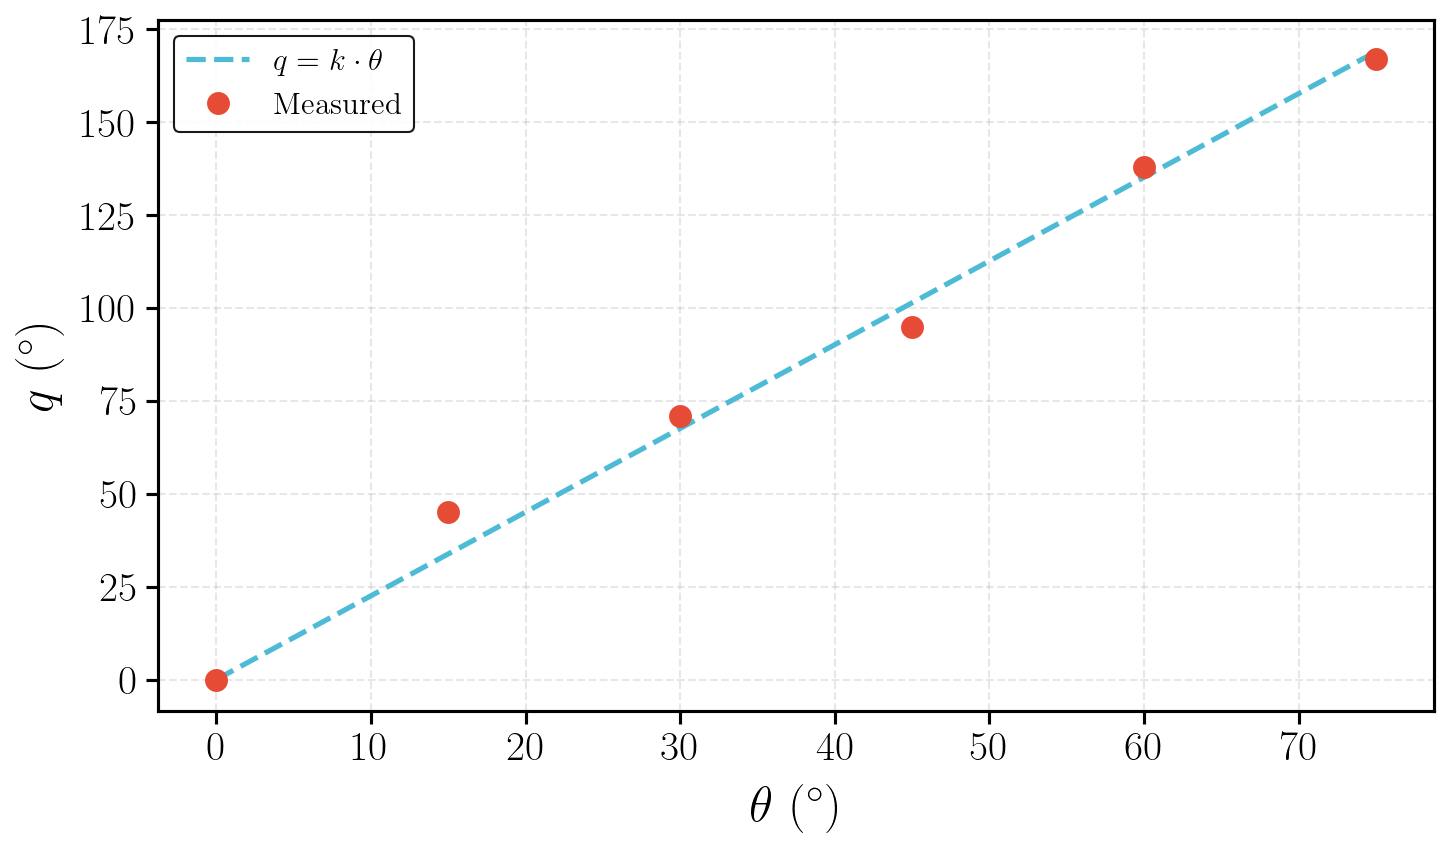

In [8]:
print("=== Middle MCP ===")
data_middle_MCP = load_joint_data('middle_MCP_joint_data.csv')
res_middle_MCP = fit_linear_model(data_middle_MCP)
print(f"  => r_pulley = r_motor / k = {0.005 / res_middle_MCP['k']:.6f} m")
plot_linear_fit(data_middle_MCP, res_middle_MCP['k'])

print("\n=== Middle PIP ===")
data_middle_PIP = load_joint_data('middle_PIP_joint_data.csv')
res_middle_PIP = fit_linear_model(data_middle_PIP)
print(f"  => c_param = k * r_motor = {res_middle_PIP['k'] * 0.005:.6f} m")
plot_linear_fit(data_middle_PIP, res_middle_PIP['k'])

---
## 4. Ring Finger

=== Ring MCP ===
Loaded 6 points from outputs/joint_data/ring_MCP_joint_data.csv
  k = 1.643636  MSE = 0.000428  R² = 0.999206
  => r_pulley = r_motor / k = 0.003042 m


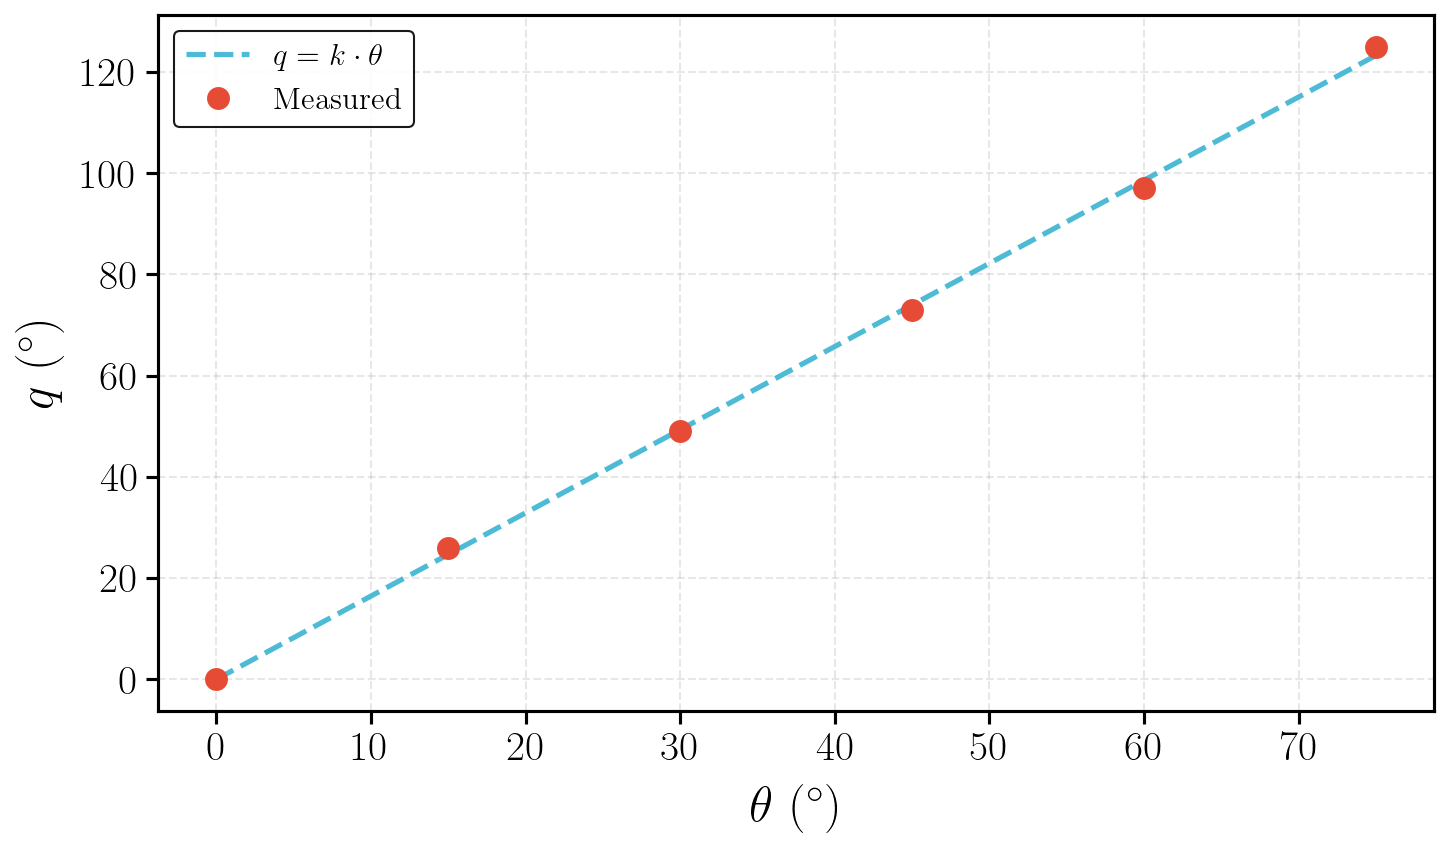


=== Ring PIP ===
Loaded 6 points from outputs/joint_data/ring_PIP_joint_data.csv
  k = 2.179394  MSE = 0.004962  R² = 0.994531
  => c_param = k * r_motor = 0.010897 m


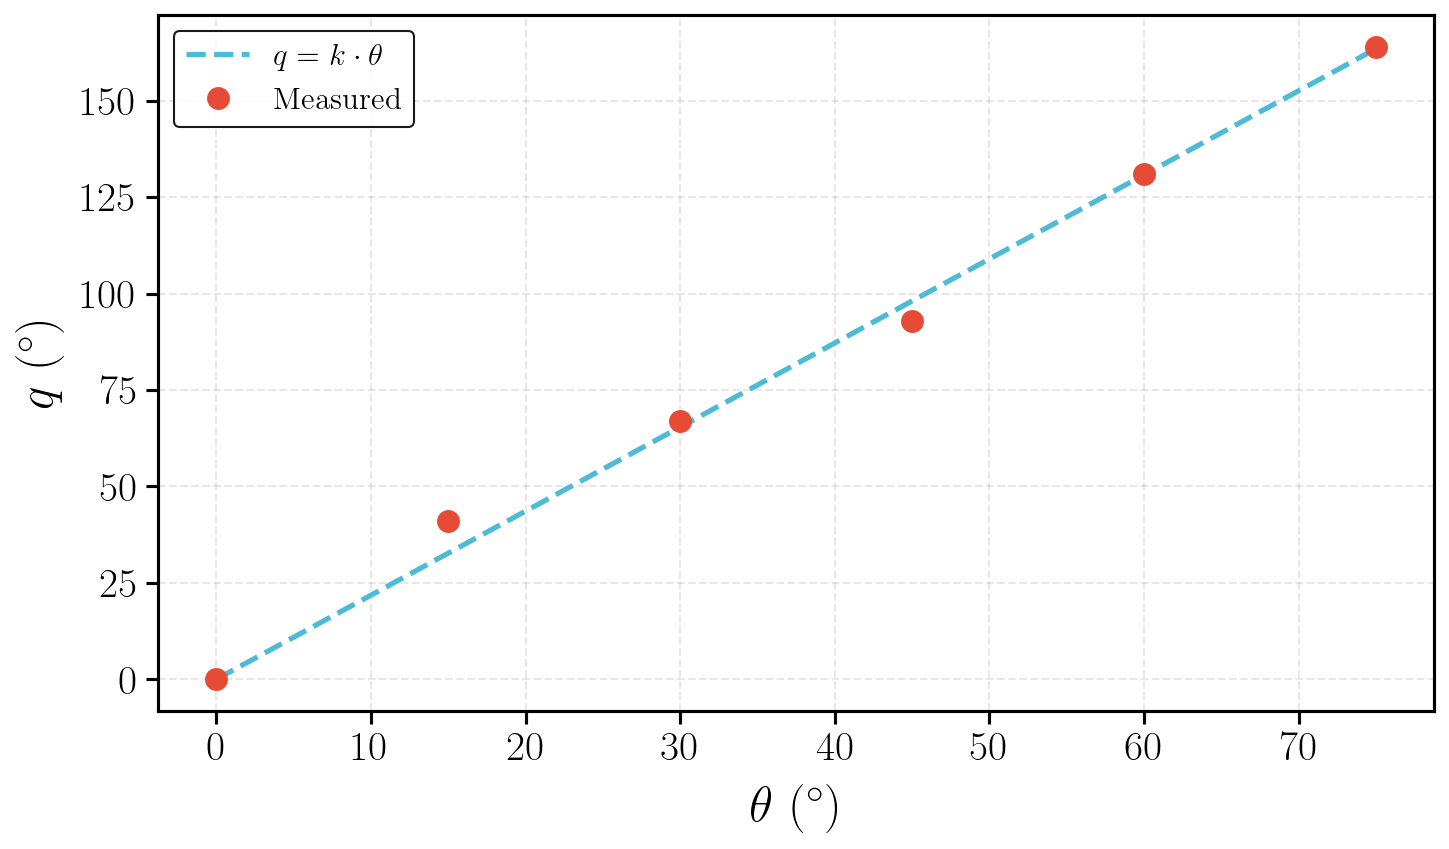

In [9]:
print("=== Ring MCP ===")
data_ring_MCP = load_joint_data('ring_MCP_joint_data.csv')
res_ring_MCP = fit_linear_model(data_ring_MCP)
print(f"  => r_pulley = r_motor / k = {0.005 / res_ring_MCP['k']:.6f} m")
plot_linear_fit(data_ring_MCP, res_ring_MCP['k'])

print("\n=== Ring PIP ===")
data_ring_PIP = load_joint_data('ring_PIP_joint_data.csv')
res_ring_PIP = fit_linear_model(data_ring_PIP)
print(f"  => c_param = k * r_motor = {res_ring_PIP['k'] * 0.005:.6f} m")
plot_linear_fit(data_ring_PIP, res_ring_PIP['k'])

---
## 5. Pinky Finger

=== Pinky MCP ===
Loaded 6 points from outputs/joint_data/pinky_MCP_joint_data.csv
  k = 1.643636  MSE = 0.000428  R² = 0.999206
  => r_pulley = r_motor / k = 0.003042 m


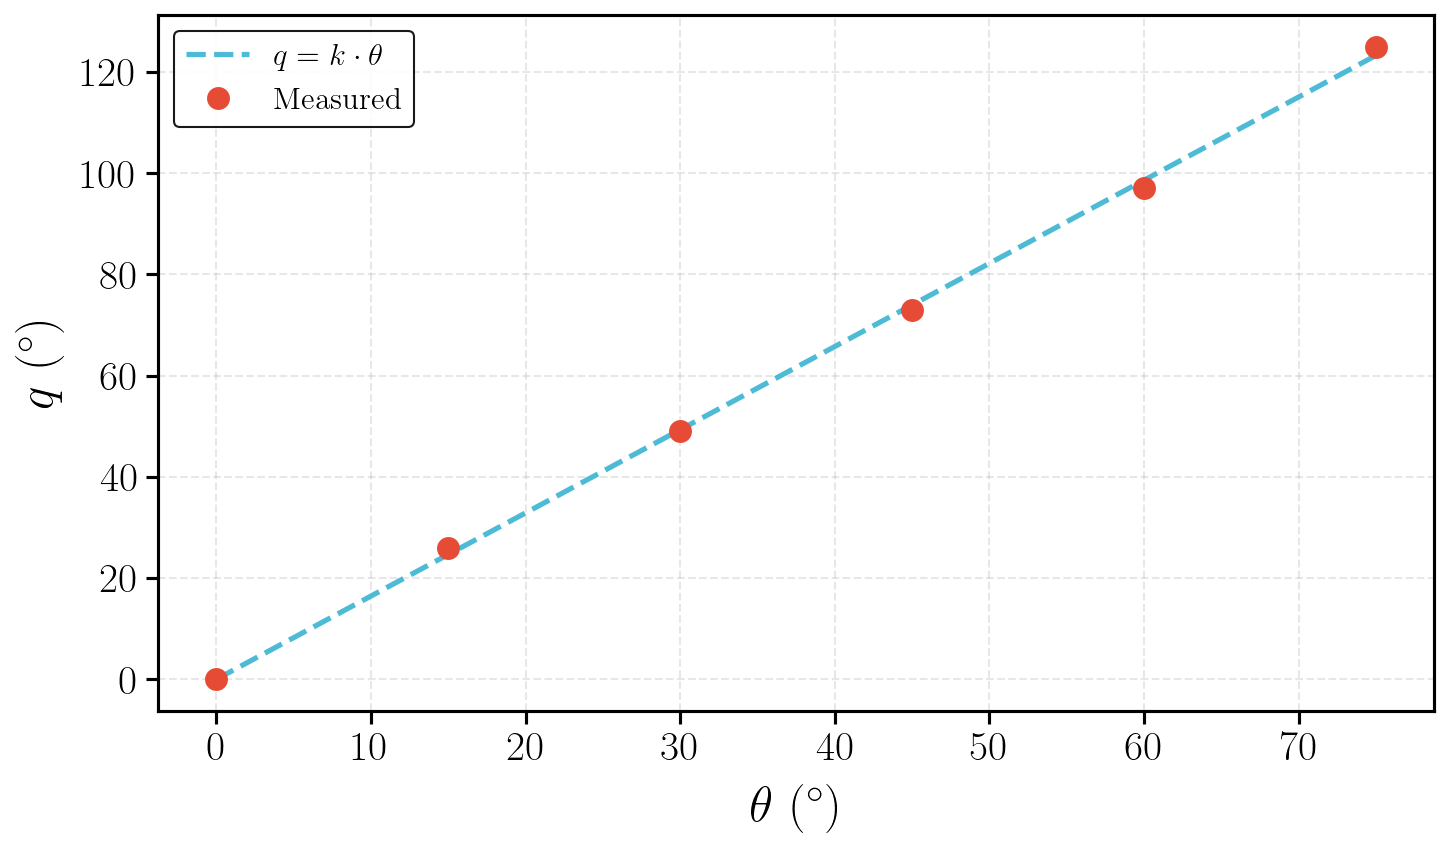


=== Pinky PIP ===
Loaded 6 points from outputs/joint_data/pinky_PIP_joint_data.csv
  k = 1.933333  MSE = 0.008479  R² = 0.989676
  => c_param = k * r_motor = 0.009667 m


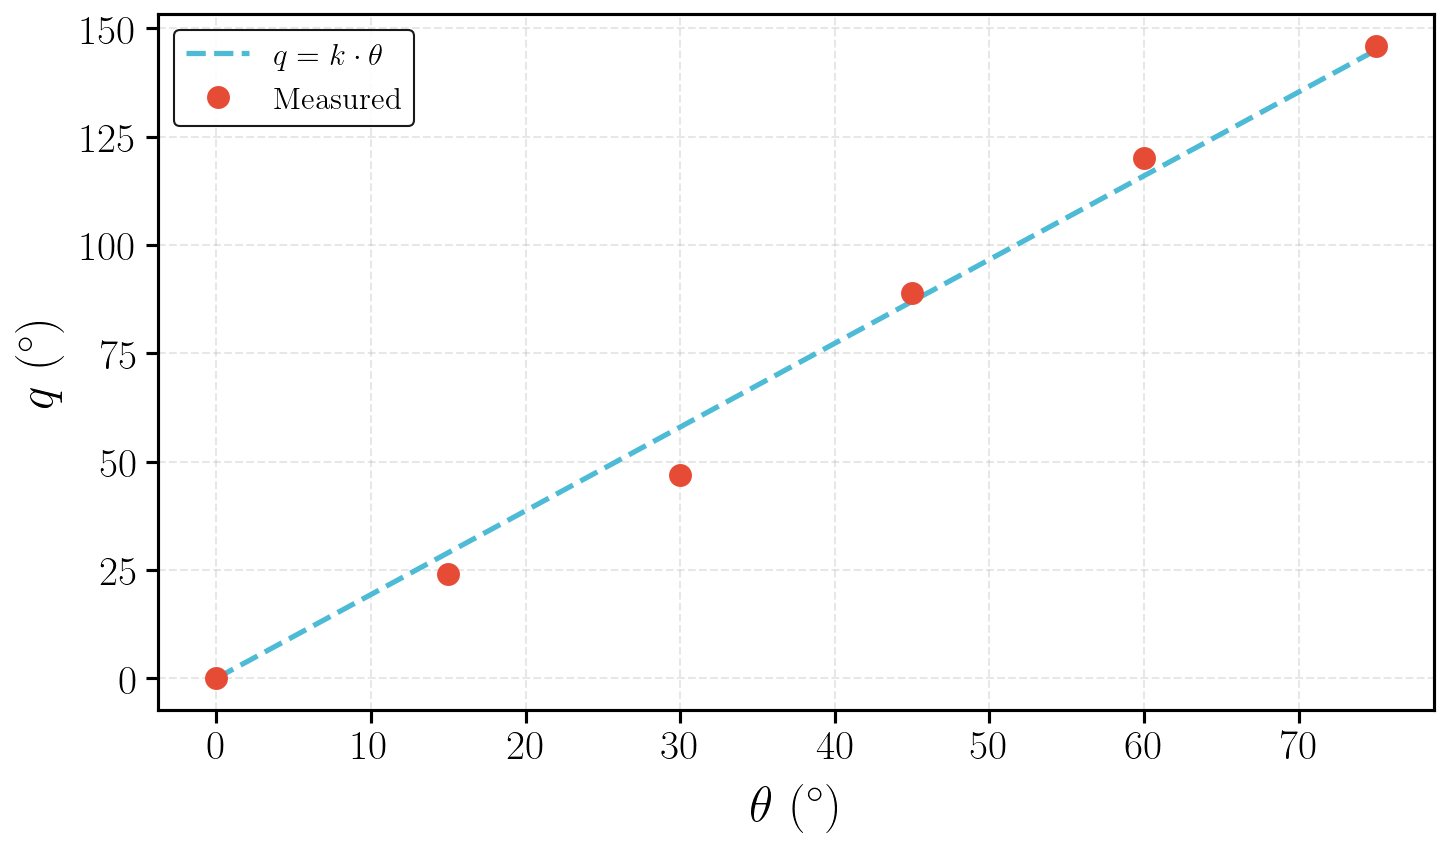

In [10]:
print("=== Pinky MCP ===")
data_pinky_MCP = load_joint_data('pinky_MCP_joint_data.csv')
res_pinky_MCP = fit_linear_model(data_pinky_MCP)
print(f"  => r_pulley = r_motor / k = {0.005 / res_pinky_MCP['k']:.6f} m")
plot_linear_fit(data_pinky_MCP, res_pinky_MCP['k'])

print("\n=== Pinky PIP ===")
data_pinky_PIP = load_joint_data('pinky_PIP_joint_data.csv')
res_pinky_PIP = fit_linear_model(data_pinky_PIP)
print(f"  => c_param = k * r_motor = {res_pinky_PIP['k'] * 0.005:.6f} m")
plot_linear_fit(data_pinky_PIP, res_pinky_PIP['k'])

---
## 6. Summary & Save to hand_params.py

In [11]:
# Collect all fitted parameters
r_motor = 0.005

fitted = {
    'thumb': {
        'CMC1_pulley': res_CMC1['r_pulley'],
        'CMC2_pulley': res_CMC2['r_pulley'],
        'MCP_c':       res_thumb_MCP['k'] * r_motor,
        'IP_c':        res_thumb_IP['k'] * r_motor,
    },
    'index': {
        'r_pulley': r_motor / res_index_MCP['k'],
        'c_param':  res_index_PIP['k'] * r_motor,
    },
    'middle': {
        'r_pulley': r_motor / res_middle_MCP['k'],
        'c_param':  res_middle_PIP['k'] * r_motor,
    },
    'ring': {
        'r_pulley': r_motor / res_ring_MCP['k'],
        'c_param':  res_ring_PIP['k'] * r_motor,
    },
    'pinky': {
        'r_pulley': r_motor / res_pinky_MCP['k'],
        'c_param':  res_pinky_PIP['k'] * r_motor,
    },
}

print("=" * 60)
print("FITTED TRANSMISSION PARAMETERS")
print("=" * 60)
print(f"\nThumb:")
print(f"  CMC1_pulley = {fitted['thumb']['CMC1_pulley']:.5f} m")
print(f"  CMC2_pulley = {fitted['thumb']['CMC2_pulley']:.5f} m")
print(f"  MCP_c       = {fitted['thumb']['MCP_c']:.5f} m")
print(f"  IP_c        = {fitted['thumb']['IP_c']:.5f} m")
for finger in ['index', 'middle', 'ring', 'pinky']:
    print(f"\n{finger.capitalize()}:")
    print(f"  r_pulley = {fitted[finger]['r_pulley']:.5f} m")
    print(f"  c_param  = {fitted[finger]['c_param']:.5f} m")

FITTED TRANSMISSION PARAMETERS

Thumb:
  CMC1_pulley = 0.01346 m
  CMC2_pulley = 0.00883 m
  MCP_c       = 0.00605 m
  IP_c        = 0.00577 m

Index:
  r_pulley = 0.00304 m
  c_param  = 0.01090 m

Middle:
  r_pulley = 0.00304 m
  c_param  = 0.01127 m

Ring:
  r_pulley = 0.00304 m
  c_param  = 0.01090 m

Pinky:
  r_pulley = 0.00304 m
  c_param  = 0.00967 m


In [12]:
# Save fitted parameters to hand_params.py
params_path = 'hand_params.py'

with open(params_path, 'r') as f:
    content = f.read()

# Update THUMB_TRANSMISSION values
content = re.sub(
    r'("CMC1_pulley":\s*)([\d.]+)',
    lambda m: f'{m.group(1)}{fitted["thumb"]["CMC1_pulley"]:.5f}',
    content
)
content = re.sub(
    r'("CMC2_pulley":\s*)([\d.]+)',
    lambda m: f'{m.group(1)}{fitted["thumb"]["CMC2_pulley"]:.5f}',
    content
)
content = re.sub(
    r'("MCP_c":\s*)([\d.]+)',
    lambda m: f'{m.group(1)}{fitted["thumb"]["MCP_c"]:.5f}',
    content
)
content = re.sub(
    r'("IP_c":\s*)([\d.]+)',
    lambda m: f'{m.group(1)}{fitted["thumb"]["IP_c"]:.5f}',
    content
)

# Update FINGER_TRANSMISSIONS values per finger
for finger in ['index', 'middle', 'ring', 'pinky']:
    # Find the finger block and update r_pulley and c_param within it
    pattern = rf'("{finger}":\s*\{{[^}}]*?"r_pulley":\s*)([\d.]+)'
    content = re.sub(
        pattern,
        lambda m, f=finger: f'{m.group(1)}{fitted[f]["r_pulley"]:.5f}',
        content
    )
    pattern = rf'("{finger}":\s*\{{[^}}]*?"c_param":\s*)([\d.]+)'
    content = re.sub(
        pattern,
        lambda m, f=finger: f'{m.group(1)}{fitted[f]["c_param"]:.5f}',
        content
    )

with open(params_path, 'w') as f:
    f.write(content)

print(f"Parameters saved to {params_path}")

Parameters saved to hand_params.py
